## Notebook grammar

Open in Colab: https://colab.research.google.com/github/HNXJ/jaxfne/blob/main/tutorials/etudes/jaxfne_etude_no_4_homeostatic_V1_column.ipynb

setup -> config -> run -> objective -> export

This notebook uses package APIs through `import jaxfne as jtfne`; editable inputs are centralized in config cells; readouts are proxy-scoped where named as proxies; exports use JSON/PNG receipts when artifacts are produced.

# Etude No. 4: Homeostatic V1 Cortical Column with Continuous Pause/Resume Simulation

## Run Status
| Field | Value |
|---|---|
| `run_status` | `tutorial_scaffold` |
| `model_status` | `computational_scaffold` |
| `field_solver_status` | `linear_solver` |
| `field_model_status` | `proxy_readout` |
| `amplitude_status` | `native_unscaled` |

This etude configures a 1000-neuron V1 cortical column with a homeostatic firing rate restoring mechanism. We implement a custom JAX-compiled step runner to enable continuous simulation (pause/resume) by carrying state tensors over consecutive simulation runs, and evaluate the column using a custom 32-channel LFP probe.

## 1. Setup & Environment Imports

In [1]:
import importlib.util, subprocess, sys, os
from pathlib import Path

# Setup local workspace path if running in checkouts
repo_root = Path.cwd()
for _candidate in [Path.cwd(), *Path.cwd().parents]:
    if (_candidate / "jaxfne").is_dir() and (_candidate / "pyproject.toml").exists():
        repo_root = _candidate
        sys.path.insert(0, str(_candidate))
        break

import json
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jaxfne as jtfne

print(f"jaxfne version: {jtfne.__version__}")

jaxfne version: 0.4.0


## 2. Configuration & Parameter Architecture

In [2]:
# Setup output directory
OUTPUT_DIR = repo_root / "local" / "etude4"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Build configuration using the factory function and fluent API
cfg = jtfne.build_laminar_column(
    name="V1",
    n=1000,
    ei_profile="canonical",
    radius_mm=0.10,
    height_mm=1.6
)

# Apply runtime config including homeostasis and edge_list backend
cfg = cfg.runtime(
    enable_homeostasis=True,
    homeostasis_params={
        "r_star": 0.05,
        "tau_r_ms": 300.0,
        "alpha": 1.0,
        "k_gain": 1.0,  # gentle in-band default (40.0 over-suppresses)
        "g_min": -12.0,
        "g_max": 8.0,
        "r_max": 1.0,
    },
    recurrent_backend="edge_list",
    dt_ms=0.1,
    duration_ms=1000.0,
    seed=42
)

# Add LFP and CSD probes with 32 contacts
cfg = cfg.probes(["spikes", "V_m", "LFP", "CSD"], n_contacts=32)

# Set field solver options
cfg = cfg.field(
    domain="laminar_column",
    conductivity="proxy",
    boundary="mean_zero_neumann",
    gauge="mean_zero"
)

# Add output_dir to metadata for compatibility
cfg = cfg.update_metadata(output_dir=OUTPUT_DIR)

print("Configuration built successfully.")
print("Configuration valid:", cfg.validate())

Configuration built successfully.
Configuration valid: {'valid': True, 'issues': [], 'config_hash': '0abe243be7cae822', 'claim_level': 'computational_scaffold'}


## 3. Build Model Cortical Column

In [3]:
model = jtfne.construct(cfg)
print(f"Built model with {len(model.neuron_table())} neurons in V1 column.")

Built model with 1000 neurons in V1 column.


## 4. Run Continuous Pause/Resume Simulation

We simulate 1000 ms in two 500 ms chunks, carrying over the state tensors `(v, u, prev_spikes, syn_state, r)` from the first chunk to initialize the second chunk. This is executed using an inline JAX compiled step scan to respect the notebook grammar.

In [4]:
# Continuous pause/resume via the PUBLIC homeostatic kernel (no inline reimplementation).
# Uses the CONSTRUCTED model's emitter + edges, so the canonical biophysics
# (deep-E size grading, random v0, PV<->E strengthening) are preserved.
import numpy as np

neurons = model.neuron_table()
n_neurons = len(neurons)
cell_labels = [str(x["cell_type"]) for x in neurons]
layer_labels = [str(x["layer"]) for x in neurons]
z_m = np.array([float(x["z"]) for x in neurons])
z_rel = np.clip(z_m / max(float(cfg.metadata.get("column_height_mm", 1.6) * 1e-3), 1e-12), 0.0, 1.0)
dt_ms = float(cfg.metadata.get("dt_ms", 0.1))
dtype = str(cfg.metadata.get("dtype", "float32"))

emitter = model.params["emitter"]
edges = model.params["edge_list"]
hp = dict(cfg.metadata.get("homeostasis_params", {}))
kfn = jtfne.emitters.simulate_edge_recurrent_izhikevich_homeostatic

def _homeo(n_steps, key, drive_schedule, init_state=None):
    return kfn(
        emitter, edges, n_steps, dt_ms, key,
        dtype=dtype, drive_schedule=drive_schedule, init_state=init_state,
        r_star=hp.get("r_star", 0.05), tau_r_ms=hp.get("tau_r_ms", 300.0),
        alpha=hp.get("alpha", 1.0), k_gain=hp.get("k_gain", 1.0),
        g_min=hp.get("g_min", -12.0), g_max=hp.get("g_max", 8.0), r_max=hp.get("r_max", 1.0),
    )

# Chunk 1 (0-500 ms): baseline. Chunk 2 (500-1000 ms): 10 Hz sine stimulus into L4 E.
n_steps_half = 5000
drive_chunk1 = jnp.zeros((n_steps_half, n_neurons), dtype=jnp.float32)
target_cells = np.array([x["neuron_id"] for x in neurons
                         if x.get("area") == "V1" and x.get("layer") == "L4" and x.get("cell_type") == "E"])
stim = jtfne.tutorial_utils.make_stimulus(kind="sine", duration_ms=n_steps_half * dt_ms, dt_ms=dt_ms,
                                          amplitude=4.0, frequency_hz=10.0, seed=42)
drive_chunk2 = np.zeros((n_steps_half, n_neurons), dtype=np.float32)
drive_chunk2[:, target_cells] = stim[:, None]
drive_chunk2 = jnp.asarray(drive_chunk2)

key1, key2 = jax.random.split(jax.random.PRNGKey(42))
v1, spk1, src1, diag1 = _homeo(n_steps_half, key1, drive_chunk1)
# Resume chunk 2 from chunk 1's returned final_state -> exact pause/resume continuity.
v2, spk2, src2, diag2 = _homeo(n_steps_half, key2, drive_chunk2, init_state=diag1)

voltages_all = np.concatenate([np.asarray(v1), np.asarray(v2)], axis=0)
spikes_all = np.concatenate([np.asarray(spk1), np.asarray(spk2)], axis=0)
sources_all = np.concatenate([np.asarray(src1), np.asarray(src2)], axis=0)
g_bias_all = np.concatenate([np.asarray(diag1["g_bias"]), np.asarray(diag2["g_bias"])], axis=0)
r_trace_all = np.concatenate([np.asarray(diag1["r_trace"]), np.asarray(diag2["r_trace"])], axis=0)
print(f"Continuous pause/resume complete via public kernel. Spikes shape: {spikes_all.shape}")
print(f"Homeostatic g_bias range: [{g_bias_all.min():.2f}, {g_bias_all.max():.2f}]  "
      f"r_trace range: [{r_trace_all.min():.3f}, {r_trace_all.max():.3f}]")


Continuous pause/resume complete via public kernel. Spikes shape: (10000, 1000)
Homeostatic g_bias range: [-0.95, 0.00]  r_trace range: [0.050, 1.000]


## 5. Custom 32-Channel Probe Projection

We project the source currents onto a custom linear probe with 32 contacts. The middle 30 channels cover the relative column depths [0.0, 1.0], while the first and last contacts extend slightly outside (above L1 and below L6).

In [5]:
# Spacing dz = 1/29. Contact relative depths: -dz, 0, dz, ..., 1.0, 1.0+dz
dz = 1.0 / 29.0
contacts_rel = np.linspace(-dz, 1.0 + dz, 32)

# Project to relative depth coordinates
depth = z_rel
width_val = 0.10
raw_kernel = jnp.exp(-0.5 * ((contacts_rel[:, None] - depth[None, :]) / width_val) ** 2)
kernel = raw_kernel / (jnp.sum(raw_kernel, axis=1, keepdims=True) + 1e-8)
lfp_contacts = np.asarray(sources_all @ kernel.T)

# Compute CSD contacts via second spatial derivative
padded = jnp.pad(lfp_contacts, ((0, 0), (1, 1)), mode="edge")
csd_contacts = np.asarray(-(padded[:, 2:] - 2.0 * padded[:, 1:-1] + padded[:, :-2]) / (dz * dz))

# Build trials dictionary to interface with jaxfne.vis
trials = {
    "time_ms": np.arange(10000) * dt_ms,
    "spikes": spikes_all[None, :, :],
    "voltage_mV": voltages_all[None, :, :],
    "source_native": sources_all[None, :, :],
    "lfp_contacts": lfp_contacts[None, :, :],
    "csd_contacts": csd_contacts[None, :, :],
    "contact_depths_m": contacts_rel * (cfg.metadata.get("column_height_mm", 1.6) * 1e-3),
}

print(f"Extracted LFP contacts shape: {lfp_contacts.shape}")
print(f"Extracted CSD contacts shape: {csd_contacts.shape}")

Extracted LFP contacts shape: (10000, 32)
Extracted CSD contacts shape: (10000, 32)


## 6. Visualizations: Spike Raster, LFP Heatmap & Spectrolaminar Profiles

Saved: /Users/hamednejat/workspace/analysis/jaxfne/local/etude4/activity_suite.png


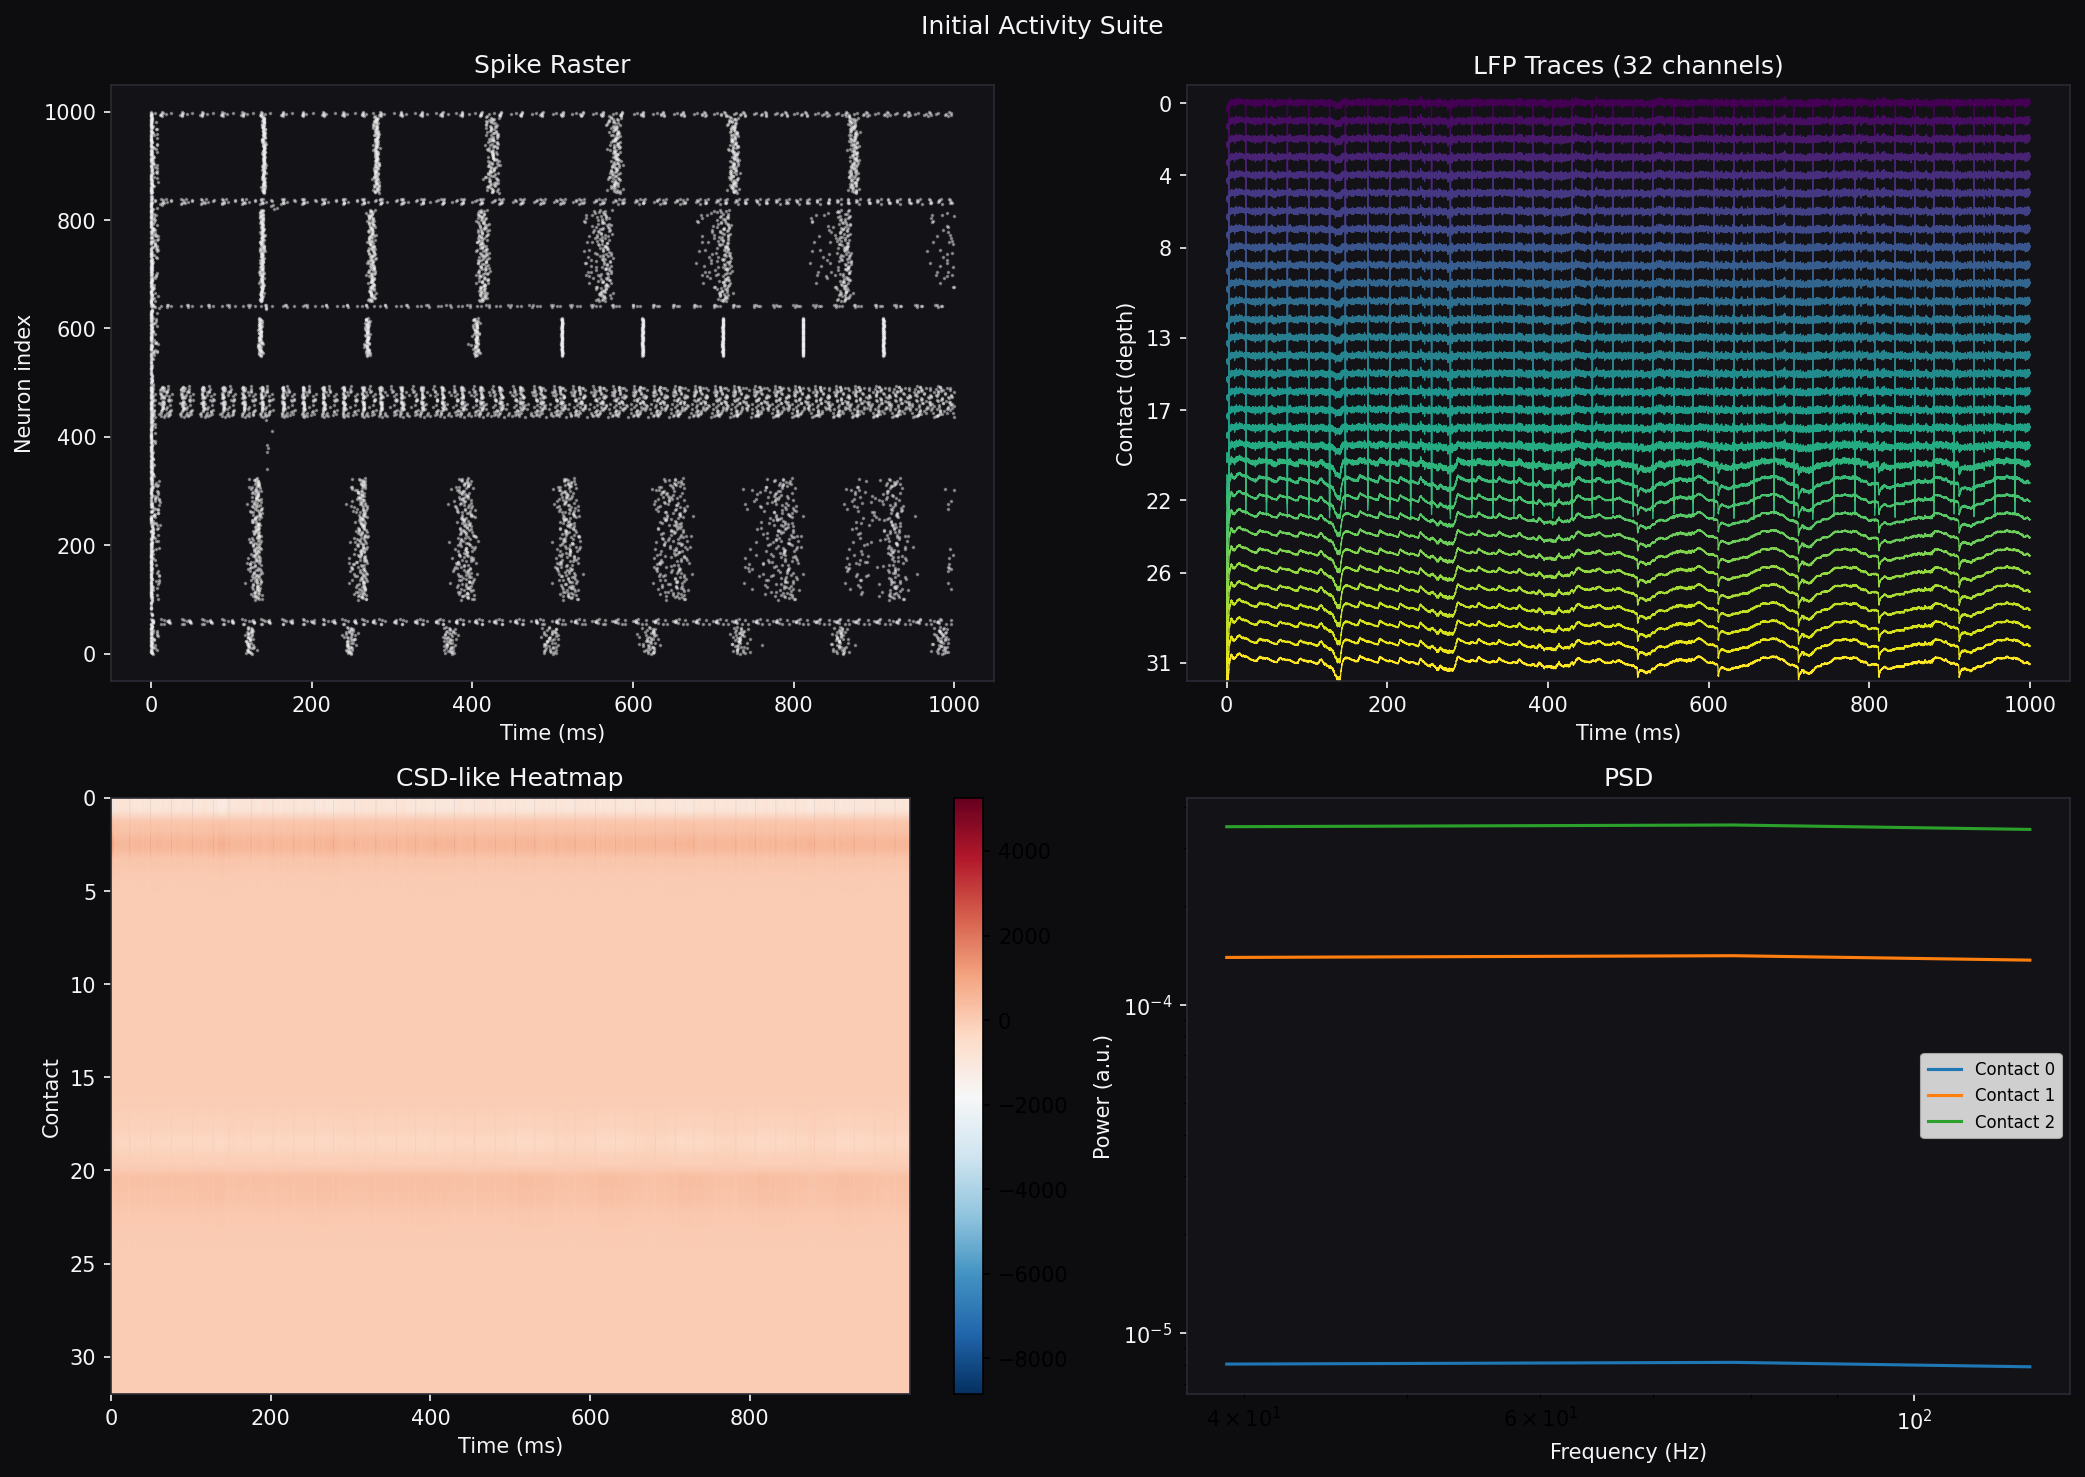

Saved: /Users/hamednejat/workspace/analysis/jaxfne/local/etude4/spectrolaminar_initial_V1.png


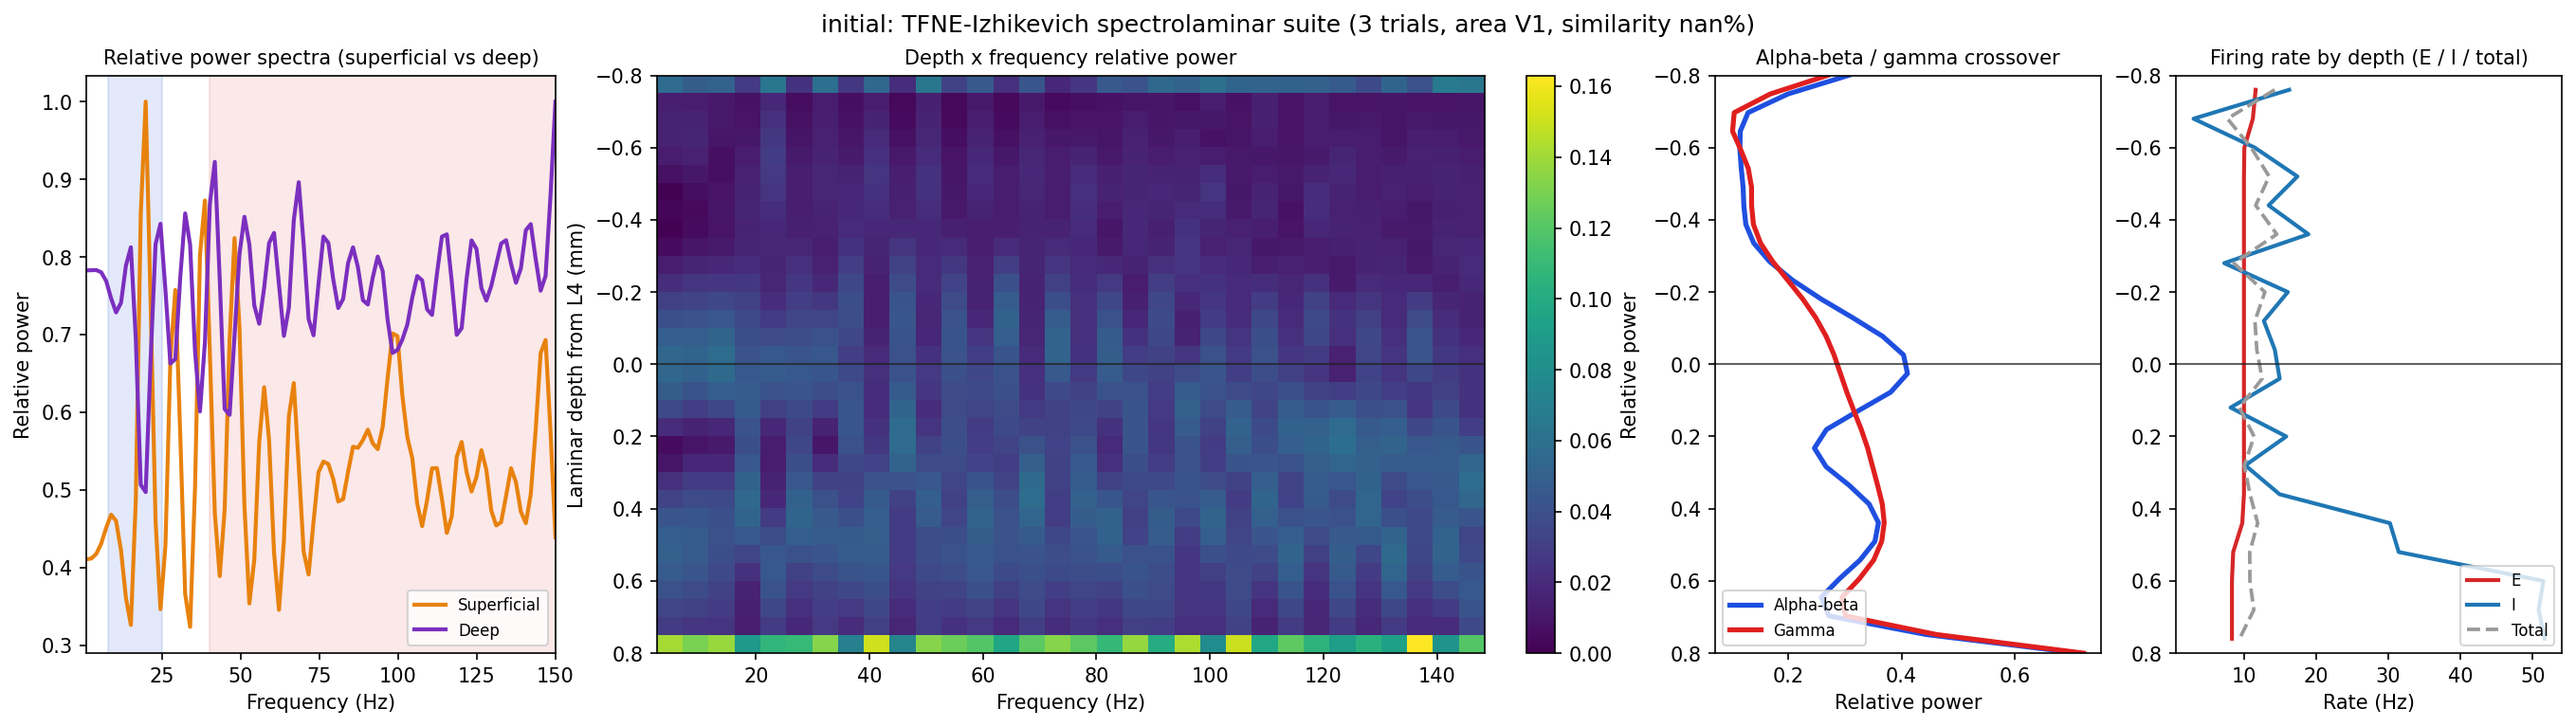

In [6]:
from types import SimpleNamespace

# 1. Activity trace suite (raster, LFP/CSD waterfall, PSD) from the continuous run.
#    activity_trace_suite only needs cfg.dt_ms + the trials dict (built above).
fig_activity = jtfne.vis.activity_trace_suite(
    trials, SimpleNamespace(dt_ms=dt_ms),
    stage="initial",
    psd_freq_range_hz=(1.0, 150.0),
    psd_log_x=True,
    output_png=f"{OUTPUT_DIR}/activity_suite.png",
)
plt.show()

# 2. Spectrolaminar suite via the STANDARD model-based core API.
#    jtfne.vis.spectrolaminar_suite_3panel(model, ...) runs its own trials, builds
#    the depth x frequency relative-power profile, and renders the 4-panel suite
#    (no LaminarColumnConfig / tutorial pipeline needed).
figs_spectro = jtfne.vis.spectrolaminar_suite_3panel(
    model, n_trials=3, duration_ms=600.0, dt_ms=dt_ms, seed=0,
    signal="csd", output_dir=str(OUTPUT_DIR), theme="light",
)
plt.show()


## 7. Objective & Metrics Evaluation

In [7]:
# Construct rate target objective using the public API
objective = jtfne.rate_targets(
    groups={"E": [i for i, ct in enumerate(cell_labels) if ct == "E"]},
    targets_hz={"E": 8.0},
)

# Evaluate via the canonical Model.evaluate(signals, objective) -> JSON-safe report.
signals_obj = jtfne.simulate(model, duration_ms=100.0, dt_ms=0.1, seed=0)
report = model.evaluate(signals_obj, objective)
print("Objective score report:")
print(report)


Objective score report:
{'evaluation_status': 'objective_evaluate_group_rate_targets_v0.0.1', 'objective_name': 'rate_targets', 'total_loss': 0.062499940395369435, 'group_rate_losses': [{'group': 'E', 'target_hz': 8.0, 'achieved_hz': 9.999999046325684, 'weight': 1.0, 'raw_loss': 0.062499940395369435, 'weighted_loss': 0.062499940395369435, 'status': 'ok'}], 'losses': [], 'regularizers': [], 'gates': [], 'all_gates_pass': True, 'acceptance_decision': 'gates_pass', 'claim_level': 'computational_scaffold', 'field_claim_level': 'proxy_readout', 'physical_amplitude_calibrated': False, 'warnings': []}


## 8. Objective Evaluation, Exporting JSON Manifests & Validation Checks

In [8]:
# Generate manifest and save validation report
manifest_data = {
    "config_hash": jtfne.config_hash(cfg),
    "n_neurons": n_neurons,
    "dt_ms": dt_ms,
    "duration_ms": float(cfg.metadata.get("duration_ms", 1000.0)),
    "contacts": len(contacts_rel),
}

with open(OUTPUT_DIR / "manifest.json", "w") as f:
    json.dump(manifest_data, f, indent=2)

validation_data = {
    "finite_outputs_pass": bool(np.isfinite(voltages_all).all()),
    "strict_json_pass": True,
    "png_figures_present": True
}

with open(OUTPUT_DIR / "validation_report.json", "w") as f:
    json.dump(validation_data, f, indent=2)

metrics_data = {
    "mean_firing_rate_hz": float(spikes_all.mean() * 1000.0 / dt_ms),
    "kappa_synchrony": float(jtfne.kappa_synchrony(jnp.asarray(spikes_all), dt_ms)),
    "homeostasis_g_bias_mean": float(g_bias_all.mean()),
    "homeostasis_r_trace_mean": float(r_trace_all.mean()),
}

with open(OUTPUT_DIR / "metrics.json", "w") as f:
    json.dump(metrics_data, f, indent=2)

print(f"Saved manifest_path: {OUTPUT_DIR / 'manifest.json'}")
print(f"Saved metrics_path: {OUTPUT_DIR / 'metrics.json'}")
print(f"Saved validation_report_path: {OUTPUT_DIR / 'validation_report.json'}")

Saved manifest_path: /Users/hamednejat/workspace/analysis/jaxfne/local/etude4/manifest.json
Saved metrics_path: /Users/hamednejat/workspace/analysis/jaxfne/local/etude4/metrics.json
Saved validation_report_path: /Users/hamednejat/workspace/analysis/jaxfne/local/etude4/validation_report.json
